# Predicción del Precio de Bolsa de Energía en Colombia
## Entrega 1: Comprensión del Problema, EDA y Baseline

**Curso:** Aprendizaje de Máquina Aplicado — EAFIT  
**Profesor:** Marco Teran  
**Estudiante:** [Tu nombre]  
**Fecha:** Abril 2026  

---

### Problema
Predecir el **precio de bolsa nacional de energía eléctrica** del día siguiente (*day-ahead*) en Colombia, usando datos históricos del mercado energético disponibles a través de la API pública de XM/SIMEM.

### Tipo de tarea
**Regresión** — variable objetivo continua: precio de bolsa ponderado nacional (COP/kWh).

### Pregunta de negocio
¿Es posible estimar con suficiente precisión el precio de bolsa del día siguiente usando variables del mercado energético colombiano (hidrología, demanda, generación) para apoyar la toma de decisiones de agentes generadores y comercializadores?


## 1. Configuración e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')

# Reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Estilo de gráficas
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette("husl")

# Rutas
DATA_DIR = "../data/raw"
FIGURES_DIR = "../figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("✓ Librerías cargadas correctamente")
print(f"✓ Directorio de figuras: {FIGURES_DIR}")


✓ Librerías cargadas correctamente
✓ Directorio de figuras: ../figures


## 2. Carga de Datos

Los datos provienen de la API pública de XM/SIMEM (Sistema de Información del Mercado de Energía Mayorista de Colombia).  
Rango temporal: **2023-02-01 a 2026-03-31** (debido a disponibilidad de Aportes Hídricos desde febrero 2023).


In [2]:
# Función auxiliar de carga
def load_csv(filename, value_col='value', rename_to=None):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path, parse_dates=['date'])
    df = df.sort_values('date').reset_index(drop=True)
    if rename_to:
        df = df.rename(columns={value_col: rename_to})
    return df

# ── Precio de Bolsa Ponderado (variable objetivo) ──
precio = load_csv('Precio_de_Bolsa_Ponderado_2023-01-01_2026-03-31.csv', rename_to='precio_bolsa')

# ── Máximo Precio Ofertado ──
mpo = load_csv('Maximo_Precio_Ofertado_2023-01-01_2026-03-31.csv')
mpo = mpo.rename(columns={'value': 'mpo_promedio_raw'})[['date','mpo_promedio','mpo_maximo']]

# ── Precio de Escasez ──
escasez = load_csv('Precio_de_Escasez_Ponderado_2023-01-01_2026-03-31.csv', rename_to='precio_escasez')

# ── Demanda Comercial ──
demanda = load_csv('Demanda_Comercial_2023-01-01_2026-03-31.csv')
demanda = demanda[['date','demanda_promedio','demanda_max','demanda_pico']]

# ── Generación Real por Tipo ──
gen = load_csv('Generacion_Real_por_Tipo_2023-01-01_2026-03-31.csv')
gen = gen[['date','gen_hidro','gen_termica','gen_solar','gen_eolica','ratio_hidro']]

# ── Aportes Hídricos en Energía ──
aportes = load_csv('Aportes_Hidricos_en_Energya_2023-01-01_2026-03-31.csv', rename_to='aportes_hidricos')

# ── Reservas Hidráulicas en % ──
reservas = load_csv('Reservas_Hidraulicas_en_-_2023-01-01_2026-03-31.csv', rename_to='reservas_pct')

# Mostrar resumen de cada archivo
datasets = {
    'Precio Bolsa': precio,
    'MPO': mpo,
    'Precio Escasez': escasez,
    'Demanda': demanda,
    'Generación': gen,
    'Aportes Hídricos': aportes,
    'Reservas %': reservas,
}

print(f"{'Dataset':<20} {'Filas':>7} {'Inicio':>12} {'Fin':>12}")
print("-" * 55)
for name, df in datasets.items():
    print(f"{name:<20} {len(df):>7} {str(df['date'].min().date()):>12} {str(df['date'].max().date()):>12}")


Dataset                Filas       Inicio          Fin
-------------------------------------------------------
Precio Bolsa            1186   2023-01-01   2026-03-31
MPO                     1186   2023-01-01   2026-03-31
Precio Escasez          1186   2023-01-01   2026-03-31
Demanda                 1186   2023-01-01   2026-03-31
Generación              1186   2023-01-01   2026-03-31
Aportes Hídricos        1155   2023-02-01   2026-03-31
Reservas %              1186   2023-01-01   2026-03-31


## 3. Integración y Limpieza del Dataset

Se realiza un **join por fecha** de todos los datasets. Se definen los límites del rango de análisis:
- **Inicio:** 2023-02-01 (disponibilidad de Aportes Hídricos)
- **Fin:** 2026-03-31


In [3]:
# Join por fecha (outer para detectar faltantes)
from functools import reduce

dfs = [precio[['date','precio_bolsa']],
       mpo,
       escasez[['date','precio_escasez']],
       demanda,
       gen,
       aportes[['date','aportes_hidricos']],
       reservas[['date','reservas_pct']]]

df = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), dfs)
df = df.sort_values('date').reset_index(drop=True)

# Filtrar rango definitivo
df = df[(df['date'] >= '2023-02-01') & (df['date'] <= '2026-03-31')].reset_index(drop=True)

print(f"Dataset integrado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Rango: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nColumnas: {list(df.columns)}")


Dataset integrado: 1155 filas × 15 columnas
Rango: 2023-02-01 → 2026-03-31

Columnas: ['date', 'precio_bolsa', 'mpo_promedio', 'mpo_maximo', 'precio_escasez', 'demanda_promedio', 'demanda_max', 'demanda_pico', 'gen_hidro', 'gen_termica', 'gen_solar', 'gen_eolica', 'ratio_hidro', 'aportes_hidricos', 'reservas_pct']


## 4. Auditoría de Calidad de Datos

Siguiendo el pipeline del curso: **inspeccionar → medir calidad → decidir**.


In [4]:
# ── 4.1 Tipos de datos ──
print("=== TIPOS DE DATOS ===")
print(df.dtypes)

# ── 4.2 Valores faltantes ──
print("\n=== VALORES FALTANTES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
missing_df = missing_df[missing_df['Faltantes'] > 0]
if len(missing_df) > 0:
    print(missing_df)
else:
    print("✓ No hay valores faltantes en el dataset integrado")

# ── 4.3 Duplicados ──
dupes = df.duplicated(subset='date').sum()
print(f"\n=== DUPLICADOS ===")
print(f"Fechas duplicadas: {dupes}")

# ── 4.4 Estadísticas descriptivas ──
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
desc = df.drop(columns='date').describe().round(2)
print(desc)


=== TIPOS DE DATOS ===
date                datetime64[us]
precio_bolsa               float64
mpo_promedio               float64
mpo_maximo                 float64
precio_escasez             float64
demanda_promedio             int64
demanda_max                  int64
demanda_pico                 int64
gen_hidro                    int64
gen_termica                  int64
gen_solar                    int64
gen_eolica                   int64
ratio_hidro                float64
aportes_hidricos           float64
reservas_pct               float64
dtype: object

=== VALORES FALTANTES ===
✓ No hay valores faltantes en el dataset integrado

=== DUPLICADOS ===
Fechas duplicadas: 0

=== ESTADÍSTICAS DESCRIPTIVAS ===
       precio_bolsa  mpo_promedio  mpo_maximo  precio_escasez  \
count       1155.00       1155.00     1155.00         1155.00   
mean         474.04        468.45      644.42          947.65   
std          374.91        381.90      467.74          103.00   
min          101.90     

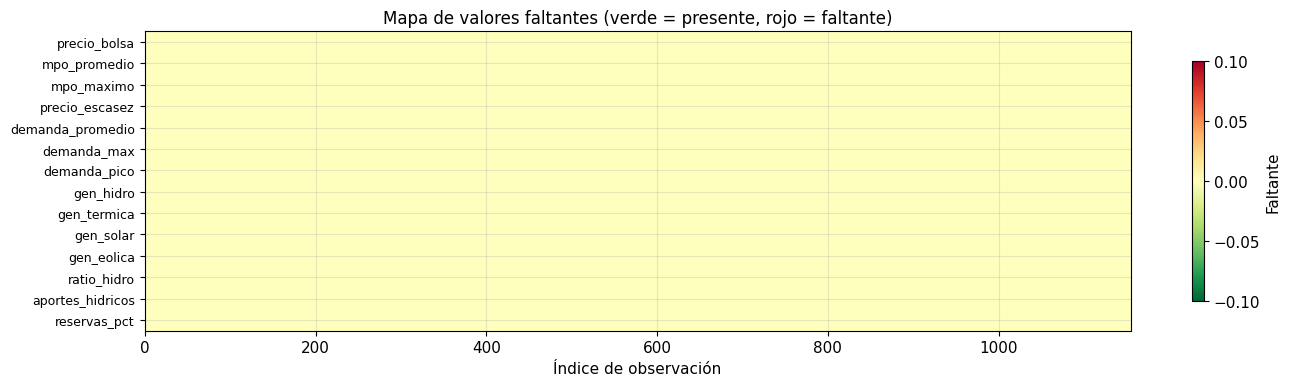

✓ Figura 1 guardada


In [5]:
# ── 4.5 Visualización de valores faltantes ──
fig, ax = plt.subplots(figsize=(14, 4))
cols_num = df.drop(columns='date').columns.tolist()
missing_matrix = df[cols_num].isnull()
im = ax.imshow(missing_matrix.T, aspect='auto', cmap='RdYlGn_r', interpolation='none')
ax.set_yticks(range(len(cols_num)))
ax.set_yticklabels(cols_num, fontsize=9)
ax.set_xlabel('Índice de observación')
ax.set_title('Mapa de valores faltantes (verde = presente, rojo = faltante)', fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.8, label='Faltante')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig1_mapa_faltantes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 1 guardada")


In [6]:
# ── 4.6 Tratamiento de faltantes ──
# Imputación con interpolación lineal (apropiada para series de tiempo continuas)
df_num = df.drop(columns='date')
df_num = df_num.interpolate(method='linear', limit_direction='both')
df[df_num.columns] = df_num

# Verificar que no quedan faltantes
assert df.isnull().sum().sum() == 0, "Aún hay valores faltantes"
print(f"✓ Imputación completada. Dataset final: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"  Mecanismo de faltantes: presumiblemente MAR (Missing At Random) — días sin publicación de XM")
print(f"  Estrategia: interpolación lineal (apropiada para series continuas de mercado)")


✓ Imputación completada. Dataset final: 1155 filas × 15 columnas
  Mecanismo de faltantes: presumiblemente MAR (Missing At Random) — días sin publicación de XM
  Estrategia: interpolación lineal (apropiada para series continuas de mercado)


## 5. Análisis Exploratorio de Datos (EDA)

### 5.1 Comportamiento de la Variable Objetivo: Precio de Bolsa


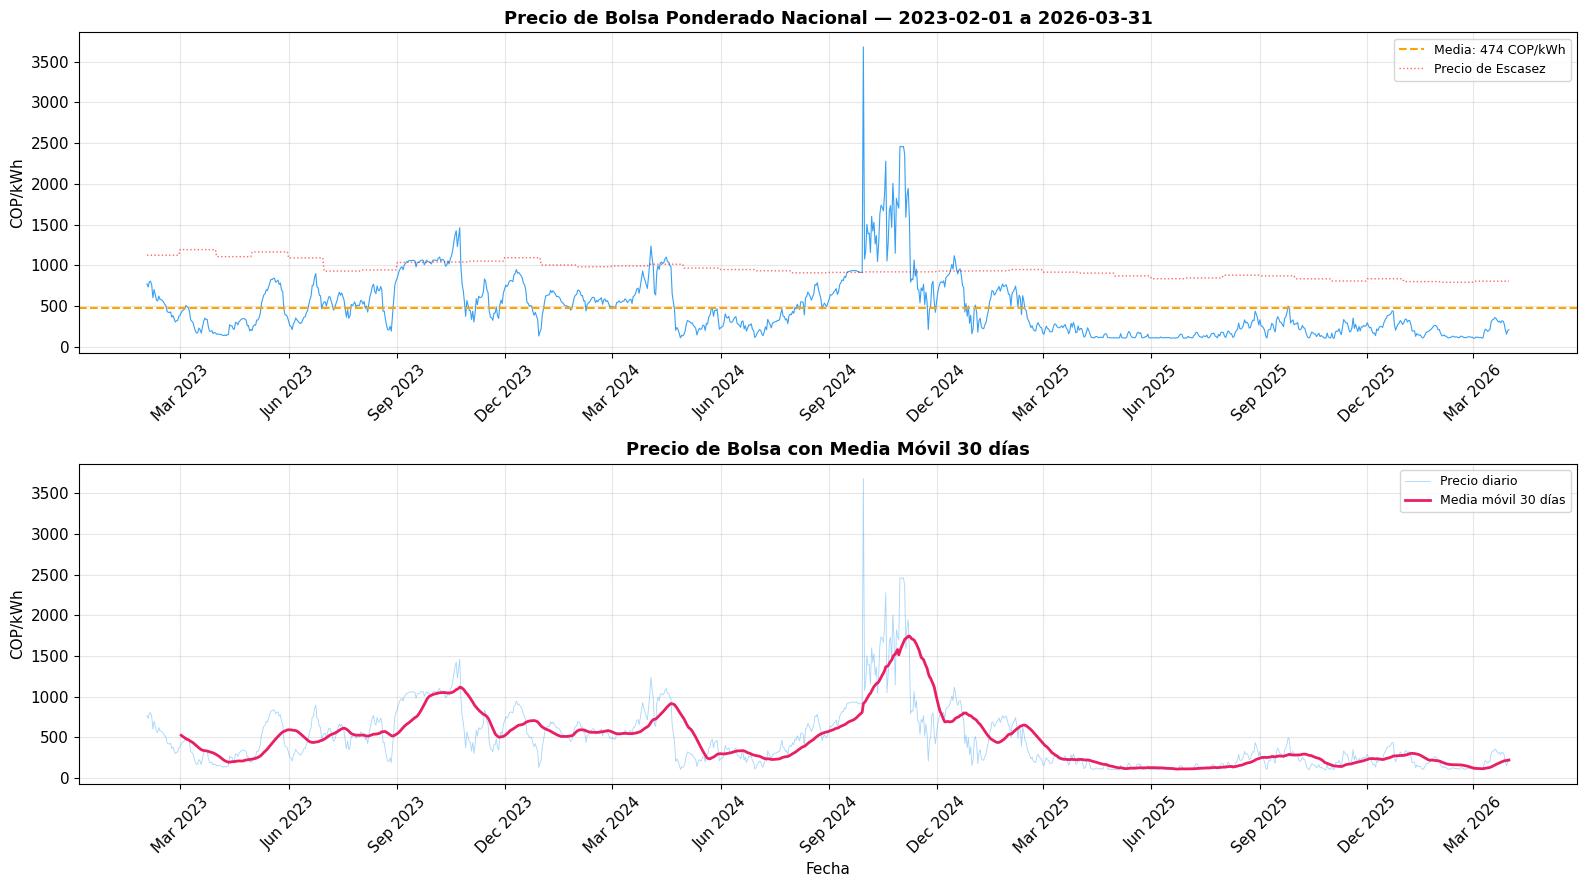

✓ Figura 2 guardada

=== ESTADÍSTICAS DEL PRECIO DE BOLSA ===
count    1155.00
mean      474.04
std       374.91
min       101.90
25%       200.58
50%       355.64
75%       644.10
max      3682.63
Name: precio_bolsa, dtype: float64

Coef. de variación: 79.1%
Ratio max/min: 36.1x

⚠ Alta volatilidad: CV > 50% indica que el RMSE será mayor que el MAE


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Serie completa
axes[0].plot(df['date'], df['precio_bolsa'], color='#2196F3', linewidth=0.8, alpha=0.9)
axes[0].set_title('Precio de Bolsa Ponderado Nacional — 2023-02-01 a 2026-03-31', fontsize=13, fontweight='bold')
axes[0].set_ylabel('COP/kWh')
axes[0].set_xlabel('')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Añadir línea de media y precio de escasez
media = df['precio_bolsa'].mean()
axes[0].axhline(media, color='orange', linestyle='--', linewidth=1.5, label=f'Media: {media:.0f} COP/kWh')
axes[0].plot(df['date'], df['precio_escasez'], color='red', linewidth=1, alpha=0.6, linestyle=':', label='Precio de Escasez')
axes[0].legend(loc='upper right', fontsize=9)

# Media móvil 30 días
ma30 = df['precio_bolsa'].rolling(30).mean()
axes[1].plot(df['date'], df['precio_bolsa'], color='#2196F3', linewidth=0.6, alpha=0.4, label='Precio diario')
axes[1].plot(df['date'], ma30, color='#E91E63', linewidth=2, label='Media móvil 30 días')
axes[1].set_title('Precio de Bolsa con Media Móvil 30 días', fontsize=13, fontweight='bold')
axes[1].set_ylabel('COP/kWh')
axes[1].set_xlabel('Fecha')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig2_serie_precio_bolsa.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 2 guardada")

# Estadísticas de la variable objetivo
print("\n=== ESTADÍSTICAS DEL PRECIO DE BOLSA ===")
stats = df['precio_bolsa'].describe()
print(stats.round(2))
print(f"\nCoef. de variación: {df['precio_bolsa'].std()/df['precio_bolsa'].mean()*100:.1f}%")
print(f"Ratio max/min: {df['precio_bolsa'].max()/df['precio_bolsa'].min():.1f}x")
print(f"\n⚠ Alta volatilidad: CV > 50% indica que el RMSE será mayor que el MAE")


### 5.2 Distribución del Precio de Bolsa

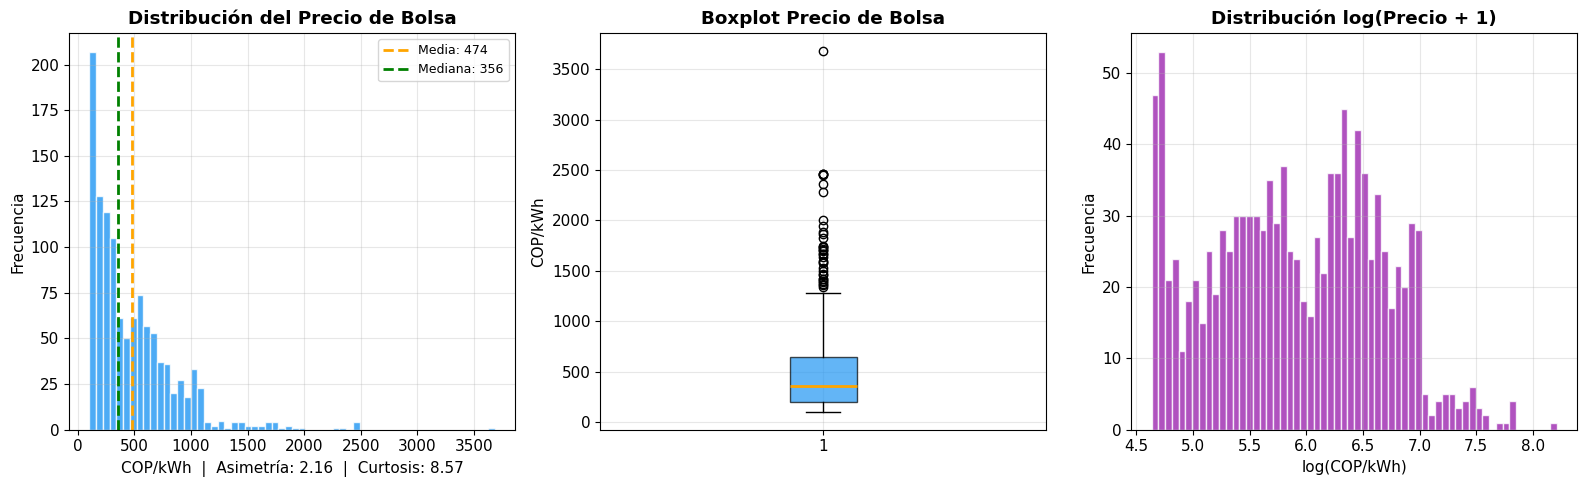

✓ Figura 3 guardada

  Asimetría (skewness): 2.16 → positiva (cola derecha)
  Curtosis: 8.57 → leptocúrtica (picos extremos)
  Interpretación: el precio NO tiene distribución normal → usar MAE y RMSE como métricas principales


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma
axes[0].hist(df['precio_bolsa'], bins=60, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(df['precio_bolsa'].mean(), color='orange', linewidth=2, linestyle='--', label=f"Media: {df['precio_bolsa'].mean():.0f}")
axes[0].axvline(df['precio_bolsa'].median(), color='green', linewidth=2, linestyle='--', label=f"Mediana: {df['precio_bolsa'].median():.0f}")
axes[0].set_title('Distribución del Precio de Bolsa', fontweight='bold')
axes[0].set_xlabel('COP/kWh')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Boxplot
axes[1].boxplot(df['precio_bolsa'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.7),
                medianprops=dict(color='orange', linewidth=2))
axes[1].set_title('Boxplot Precio de Bolsa', fontweight='bold')
axes[1].set_ylabel('COP/kWh')
axes[1].set_xlabel('')

# Log-distribución
axes[2].hist(np.log1p(df['precio_bolsa']), bins=60, color='#9C27B0', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribución log(Precio + 1)', fontweight='bold')
axes[2].set_xlabel('log(COP/kWh)')
axes[2].set_ylabel('Frecuencia')

# Estadísticas de forma
from scipy import stats as scipy_stats
skew = scipy_stats.skew(df['precio_bolsa'])
kurt = scipy_stats.kurtosis(df['precio_bolsa'])
axes[0].set_xlabel(f'COP/kWh  |  Asimetría: {skew:.2f}  |  Curtosis: {kurt:.2f}')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig3_distribucion_precio.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 3 guardada")
print(f"\n  Asimetría (skewness): {skew:.2f} → {'positiva (cola derecha)' if skew > 0 else 'negativa'}")
print(f"  Curtosis: {kurt:.2f} → {'leptocúrtica (picos extremos)' if kurt > 3 else 'mesocúrtica'}")
print(f"  Interpretación: el precio NO tiene distribución normal → usar MAE y RMSE como métricas principales")


### 5.3 Comportamiento de las Variables Predictoras

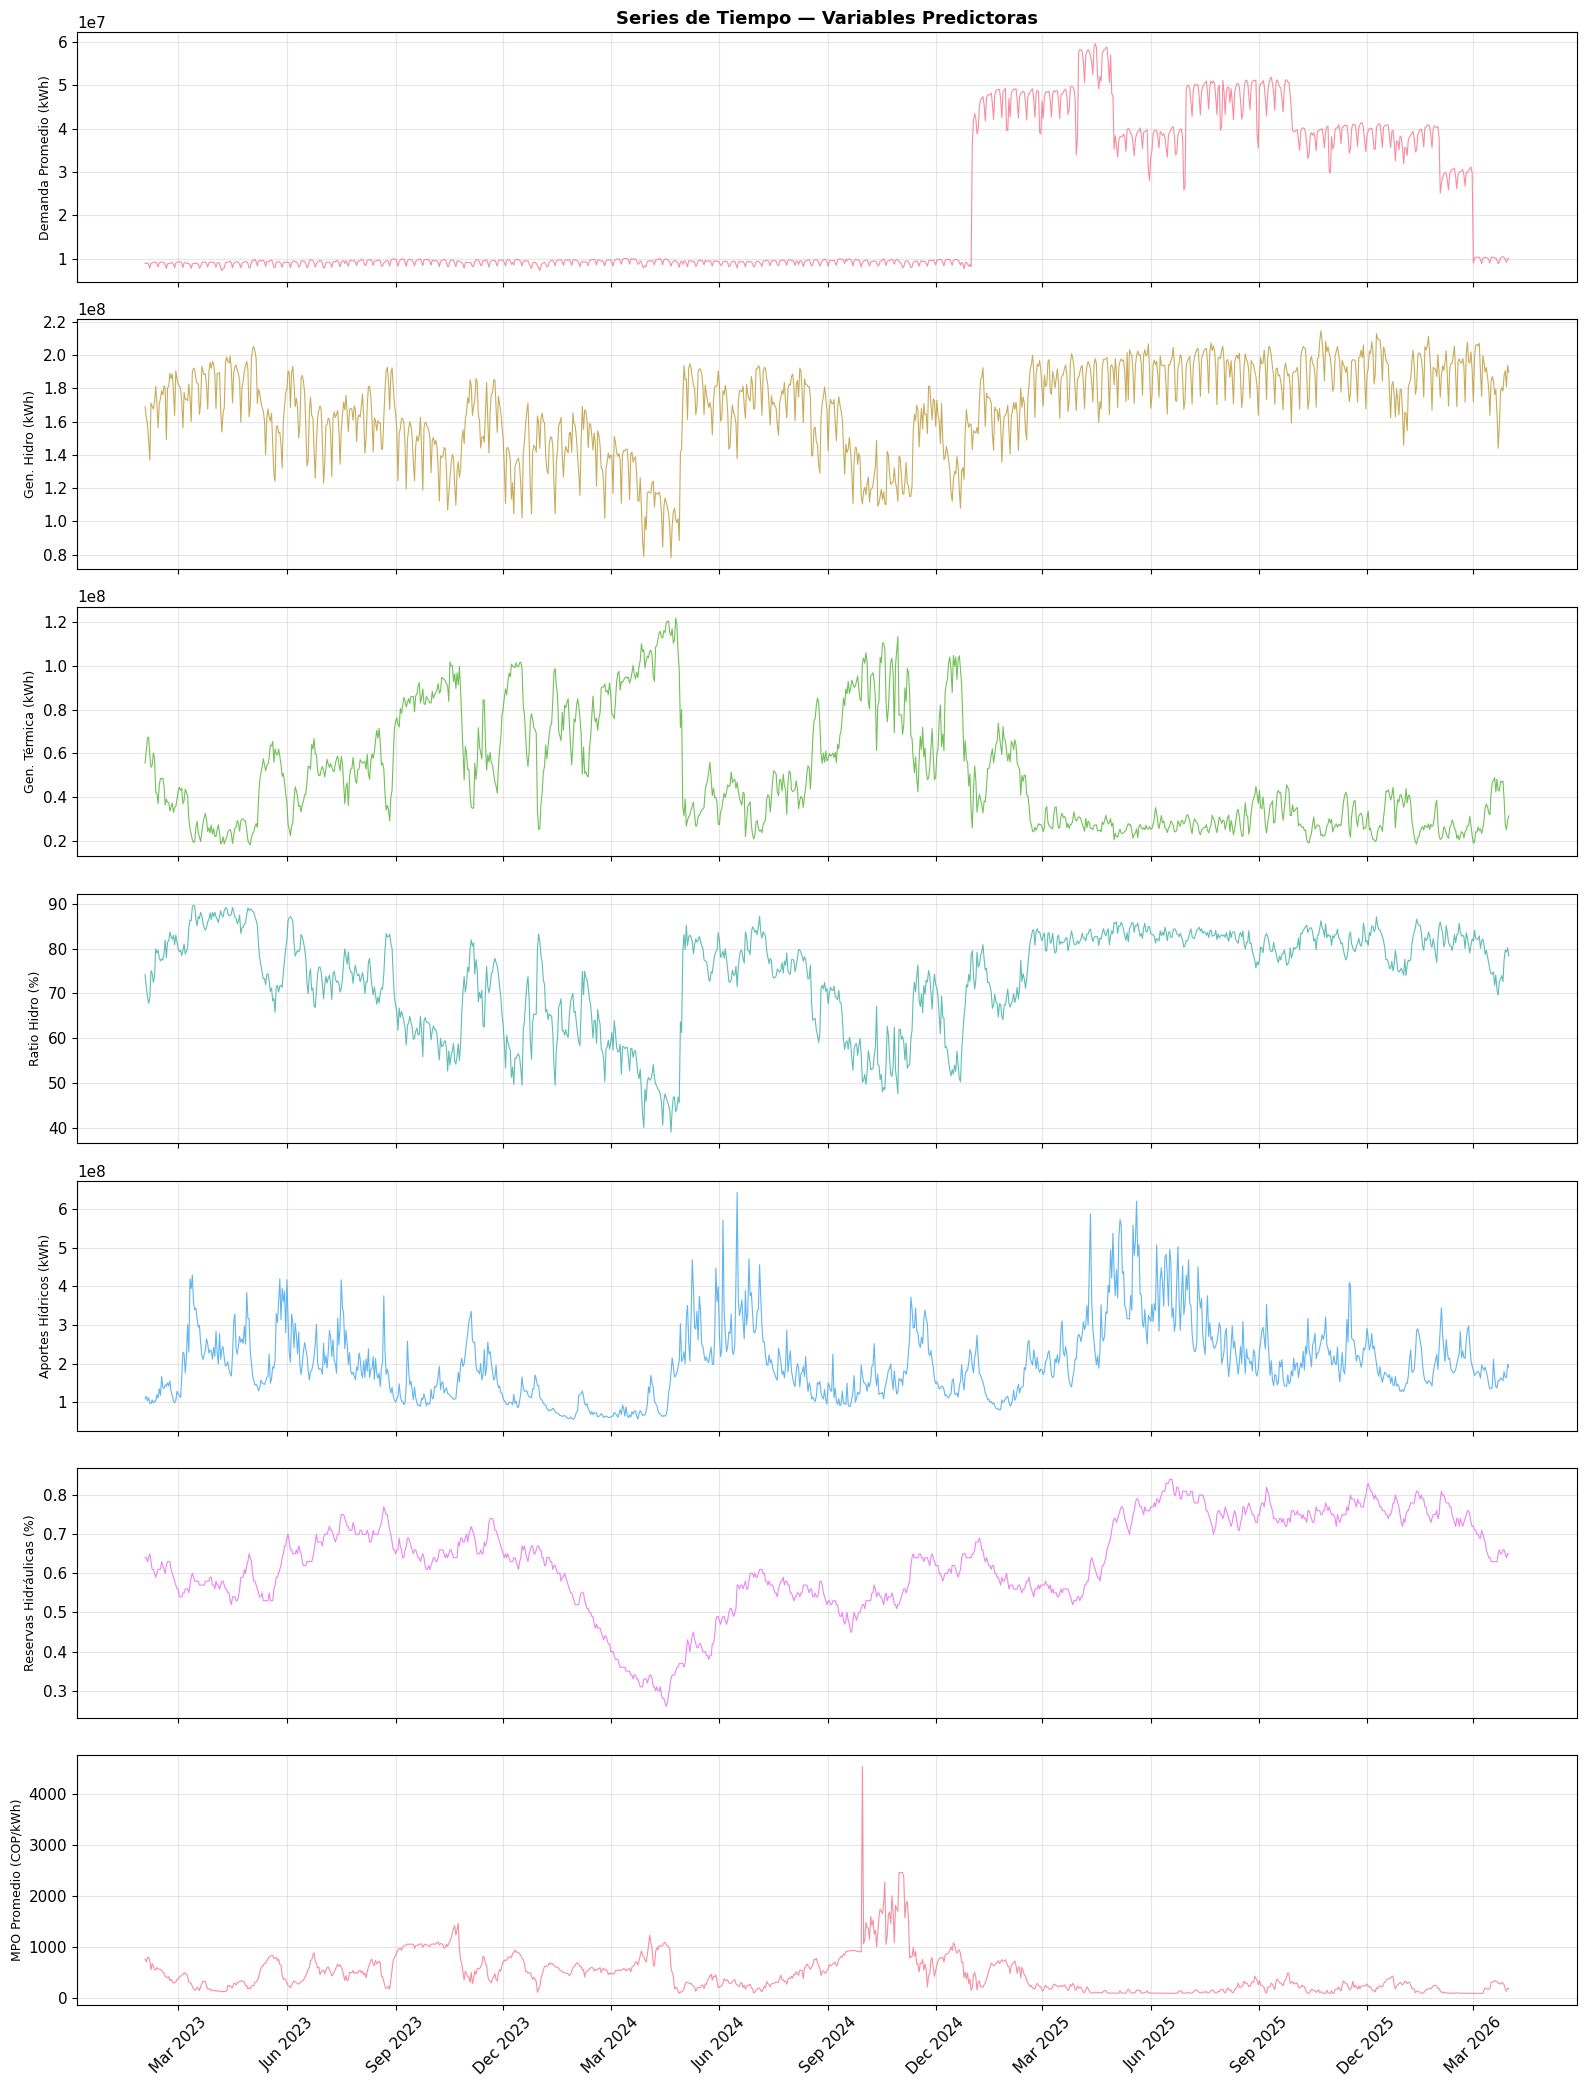

✓ Figura 4 guardada


In [9]:
predictores = {
    'Demanda Promedio (kWh)': 'demanda_promedio',
    'Gen. Hidro (kWh)': 'gen_hidro',
    'Gen. Térmica (kWh)': 'gen_termica',
    'Ratio Hidro (%)': 'ratio_hidro',
    'Aportes Hídricos (kWh)': 'aportes_hidricos',
    'Reservas Hidráulicas (%)': 'reservas_pct',
    'MPO Promedio (COP/kWh)': 'mpo_promedio',
}

fig, axes = plt.subplots(len(predictores), 1, figsize=(16, 3*len(predictores)))

for i, (nombre, col) in enumerate(predictores.items()):
    axes[i].plot(df['date'], df[col], linewidth=0.8, alpha=0.8, color=f'C{i}')
    axes[i].set_ylabel(nombre, fontsize=9)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[i].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    if i < len(predictores) - 1:
        axes[i].set_xticklabels([])
    else:
        plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45)

axes[0].set_title('Series de Tiempo — Variables Predictoras', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig4_series_predictoras.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 4 guardada")


### 5.4 Matriz de Correlaciones

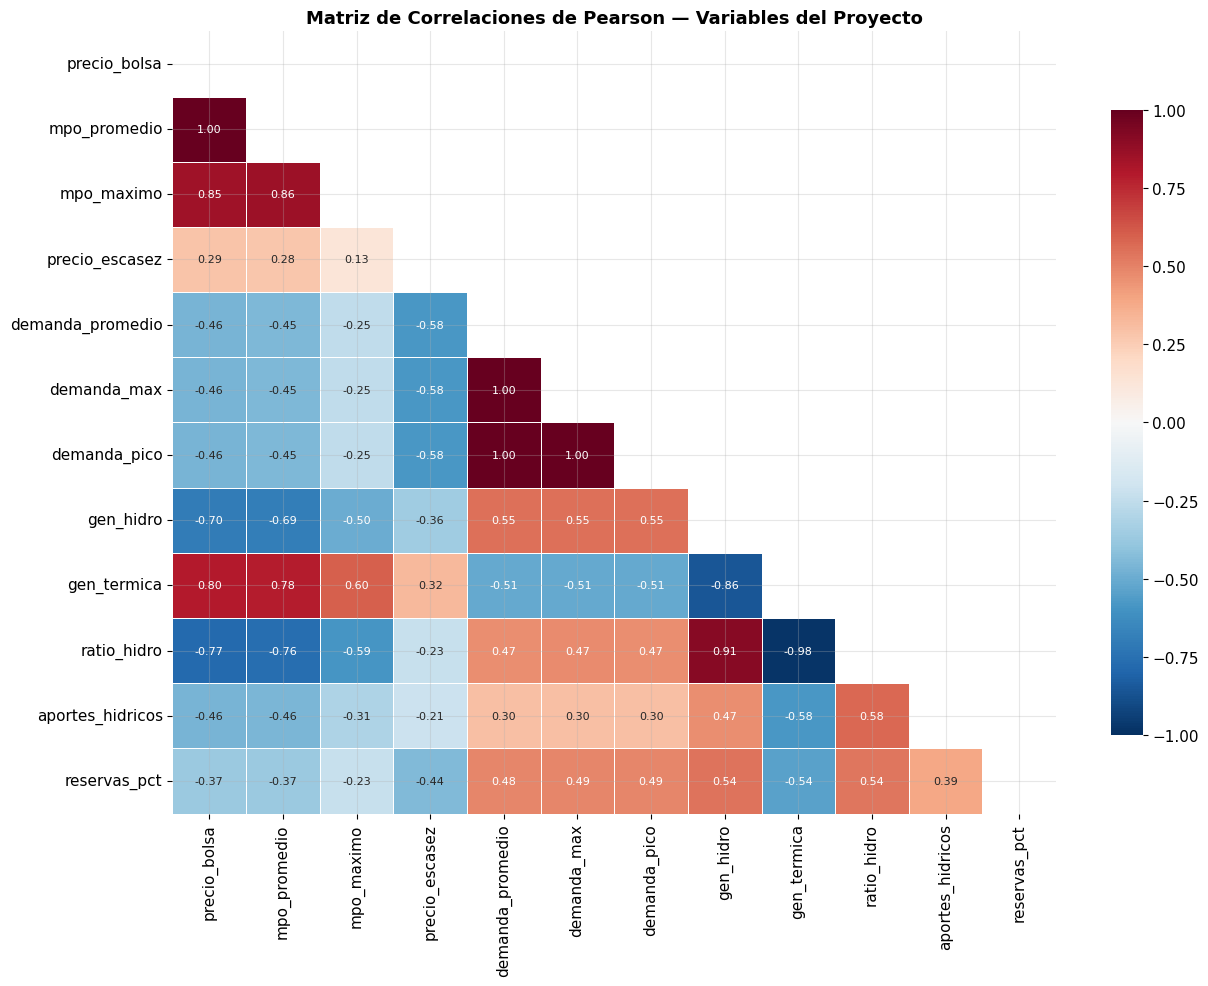


=== CORRELACIONES CON PRECIO DE BOLSA (ordenadas por magnitud) ===
mpo_promedio        0.998
mpo_maximo          0.847
gen_termica         0.795
ratio_hidro        -0.774
gen_hidro          -0.701
demanda_max        -0.462
demanda_pico       -0.462
aportes_hidricos   -0.461
demanda_promedio   -0.461
reservas_pct       -0.374
precio_escasez      0.285
Name: precio_bolsa, dtype: float64
✓ Figura 5 guardada


In [10]:
cols_corr = ['precio_bolsa', 'mpo_promedio', 'mpo_maximo', 'precio_escasez',
             'demanda_promedio', 'demanda_max', 'demanda_pico',
             'gen_hidro', 'gen_termica', 'ratio_hidro',
             'aportes_hidricos', 'reservas_pct']

corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlaciones de Pearson — Variables del Proyecto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig5_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlaciones con la variable objetivo, ordenadas
corr_target = corr_matrix['precio_bolsa'].drop('precio_bolsa').sort_values(key=abs, ascending=False)
print("\n=== CORRELACIONES CON PRECIO DE BOLSA (ordenadas por magnitud) ===")
print(corr_target.round(3))
print("✓ Figura 5 guardada")


### 5.5 Estacionalidad y Patrones Temporales

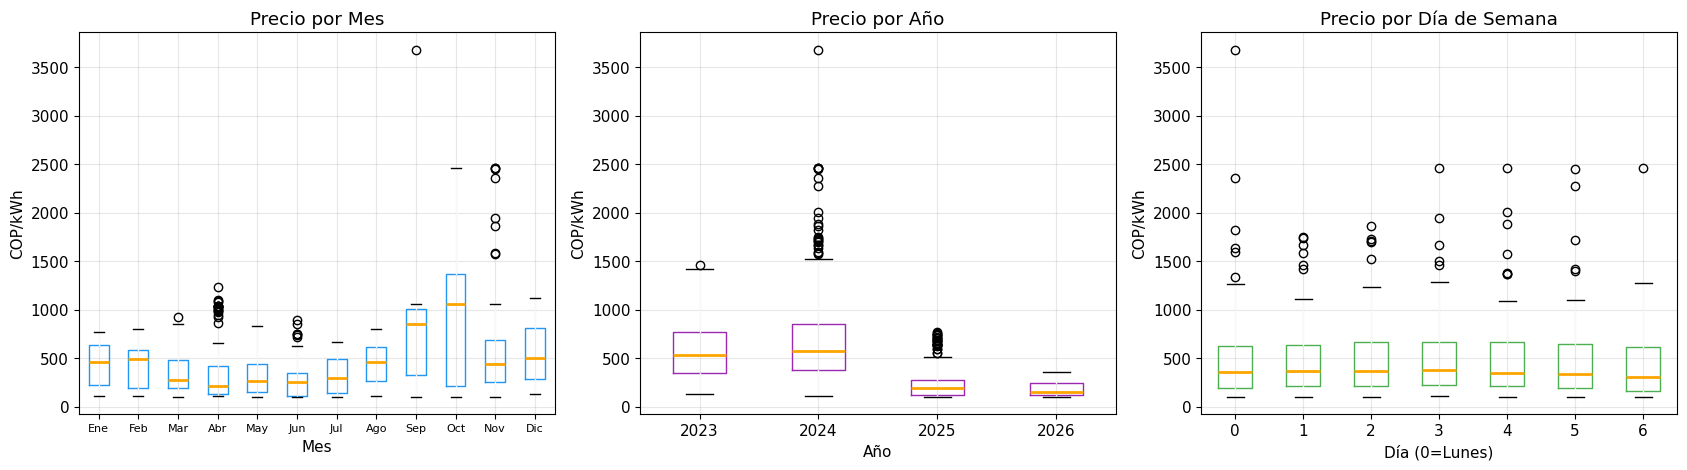

✓ Figura 6 guardada

=== PRECIO MEDIO POR MES ===
      mean  median    std
mes                      
1    432.1   464.3  207.0
2    415.7   488.8  215.6
3    341.4   276.3  192.5
4    373.6   210.0  348.0
5    332.8   262.3  231.1
6    286.3   260.0  189.3
7    314.9   298.6  176.8
8    445.9   462.2  198.5
9    738.2   855.5  451.3
10   910.8  1056.9  622.4
11   596.2   443.3  528.9
12   560.4   503.9  281.8


In [11]:
df['mes'] = df['date'].dt.month
df['anio'] = df['date'].dt.year
df['dia_semana'] = df['date'].dt.dayofweek

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Box plot por mes
df.boxplot(column='precio_bolsa', by='mes', ax=axes[0],
           boxprops=dict(color='#2196F3'),
           medianprops=dict(color='orange', linewidth=2))
axes[0].set_title('Precio por Mes', fontweight='bold')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('COP/kWh')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], fontsize=8)
plt.sca(axes[0]); plt.title('Precio por Mes')

# Box plot por año
df.boxplot(column='precio_bolsa', by='anio', ax=axes[1],
           boxprops=dict(color='#9C27B0'),
           medianprops=dict(color='orange', linewidth=2))
axes[1].set_title('Precio por Año', fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('COP/kWh')
plt.sca(axes[1]); plt.title('Precio por Año')

# Box plot por día de semana
df.boxplot(column='precio_bolsa', by='dia_semana', ax=axes[2],
           boxprops=dict(color='#4CAF50'),
           medianprops=dict(color='orange', linewidth=2))
axes[2].set_title('Precio por Día de Semana', fontweight='bold')
axes[2].set_xlabel('Día (0=Lunes)')
axes[2].set_ylabel('COP/kWh')
plt.sca(axes[2]); plt.title('Precio por Día de Semana')

plt.suptitle('')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig6_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 6 guardada")

# Precio medio por mes
print("\n=== PRECIO MEDIO POR MES ===")
print(df.groupby('mes')['precio_bolsa'].agg(['mean','median','std']).round(1))


## 6. Feature Engineering

Construcción de variables temporales y lags del precio siguiendo las recomendaciones de la literatura:
- El precio tiene **memoria corta (1-2 días)** — lags de 1, 2 y 7 días
- Variables de calendario: mes, día de semana, festivos colombianos
- Media móvil de 7 y 30 días


In [12]:
# Festivos colombianos aproximados (Ley Emiliani + festivos fijos)
festivos = []
for anio in [2023, 2024, 2025, 2026]:
    festivos += [
        f'{anio}-01-01', f'{anio}-05-01', f'{anio}-07-20',
        f'{anio}-08-07', f'{anio}-12-08', f'{anio}-12-25',
    ]
festivos = pd.to_datetime(festivos)

# Variables de calendario
df['mes'] = df['date'].dt.month
df['dia_semana'] = df['date'].dt.dayofweek
df['es_fin_semana'] = (df['dia_semana'] >= 5).astype(int)
df['es_festivo'] = df['date'].isin(festivos).astype(int)
df['trimestre'] = df['date'].dt.quarter

# Temporada hidrológica
# Colombia: seco (dic-mar=1), transición húmeda (abr-may=2), húmedo (jun-sep=3), transición seca (oct-nov=4)
def temporada_hidro(mes):
    if mes in [12, 1, 2, 3]: return 1  # Seco
    elif mes in [4, 5]: return 2        # Transición húmeda
    elif mes in [6, 7, 8, 9]: return 3  # Húmedo
    else: return 4                       # Transición seca

df['temporada_hidro'] = df['mes'].map(temporada_hidro)

# Lags del precio de bolsa
df['precio_lag1'] = df['precio_bolsa'].shift(1)
df['precio_lag2'] = df['precio_bolsa'].shift(2)
df['precio_lag7'] = df['precio_bolsa'].shift(7)

# Medias móviles
df['precio_ma7']  = df['precio_bolsa'].shift(1).rolling(7).mean()
df['precio_ma30'] = df['precio_bolsa'].shift(1).rolling(30).mean()

# Lag de demanda y aportes
df['demanda_lag1']    = df['demanda_promedio'].shift(1)
df['aportes_ma7']     = df['aportes_hidricos'].shift(1).rolling(7).mean()
df['ratio_reserva']   = df['reservas_pct'] / (df['aportes_hidricos'] / df['aportes_hidricos'].mean() + 0.01)

print(f"Dataset con features: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nFeatures construidos:")
nuevas = ['mes','dia_semana','es_fin_semana','es_festivo','trimestre','temporada_hidro',
          'precio_lag1','precio_lag2','precio_lag7','precio_ma7','precio_ma30',
          'demanda_lag1','aportes_ma7','ratio_reserva']
for f in nuevas:
    print(f"  + {f}")


Dataset con features: 1155 filas × 30 columnas

Features construidos:
  + mes
  + dia_semana
  + es_fin_semana
  + es_festivo
  + trimestre
  + temporada_hidro
  + precio_lag1
  + precio_lag2
  + precio_lag7
  + precio_ma7
  + precio_ma30
  + demanda_lag1
  + aportes_ma7
  + ratio_reserva


## 7. Split Temporal

**Crítico:** en series de tiempo NO se puede hacer split aleatorio — causaría data leakage.  
Se usa división cronológica estricta:

- **Entrenamiento:** 2023-02-01 a 2024-12-31 (~22 meses)
- **Validación:** 2025-01-01 a 2025-06-30 (~6 meses)
- **Prueba (test):** 2025-07-01 a 2026-03-31 (~9 meses)


In [13]:
# Eliminar filas con NaN generados por lags/rolling
df_model = df.dropna().reset_index(drop=True)

TRAIN_END   = '2024-12-31'
VAL_END     = '2025-06-30'

train = df_model[df_model['date'] <= TRAIN_END].copy()
val   = df_model[(df_model['date'] > TRAIN_END) & (df_model['date'] <= VAL_END)].copy()
test  = df_model[df_model['date'] > VAL_END].copy()

print(f"{'Split':<15} {'Inicio':>12} {'Fin':>12} {'Filas':>7} {'%':>6}")
print("-" * 55)
print(f"{'Entrenamiento':<15} {str(train['date'].min().date()):>12} {str(train['date'].max().date()):>12} {len(train):>7} {len(train)/len(df_model)*100:>5.1f}%")
print(f"{'Validación':<15} {str(val['date'].min().date()):>12} {str(val['date'].max().date()):>12} {len(val):>7} {len(val)/len(df_model)*100:>5.1f}%")
print(f"{'Test':<15} {str(test['date'].min().date()):>12} {str(test['date'].max().date()):>12} {len(test):>7} {len(test)/len(df_model)*100:>5.1f}%")
print(f"\n✓ Split temporal correcto — NO hay data leakage entre conjuntos")
print(f"✓ El test set NO se toca hasta la evaluación final")

# Definir features y target
FEATURES = ['precio_lag1', 'precio_lag2', 'precio_lag7', 'precio_ma7', 'precio_ma30',
            'demanda_promedio', 'demanda_lag1', 'demanda_pico',
            'gen_hidro', 'gen_termica', 'ratio_hidro',
            'aportes_hidricos', 'aportes_ma7',
            'reservas_pct', 'ratio_reserva',
            'mpo_promedio', 'mpo_maximo',
            'mes', 'dia_semana', 'es_fin_semana', 'es_festivo', 'temporada_hidro']

TARGET = 'precio_bolsa'

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"\nFeatures: {len(FEATURES)}")
print(f"Target: {TARGET}")


Split                 Inicio          Fin   Filas      %
-------------------------------------------------------
Entrenamiento     2023-03-03   2024-12-31     670  59.6%
Validación        2025-01-01   2025-06-30     181  16.1%
Test              2025-07-01   2026-03-31     274  24.4%

✓ Split temporal correcto — NO hay data leakage entre conjuntos
✓ El test set NO se toca hasta la evaluación final

Features: 22
Target: precio_bolsa


## 8. Baselines Reproducibles

Se construyen dos baselines que no requieren entrenamiento, usando solo el historial del precio:

- **Baseline 1 — Persistencia:** precio_mañana = precio_hoy
- **Baseline 2 — Media móvil 7 días:** precio_mañana = promedio(últimos 7 días)

Estos son los puntos de referencia mínimos que cualquier modelo debe superar.


In [14]:
def calcular_metricas(y_real, y_pred, nombre):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    media_real = y_real.mean()
    return {
        'Modelo': nombre,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'MAE/Media (%)': round(mae/media_real*100, 1),
    }

resultados = []

# ── Baseline 1: Persistencia ──
y_persist_val  = val['precio_lag1'].values
y_persist_test = test['precio_lag1'].values

resultados.append(calcular_metricas(y_val.values,  y_persist_val,  'B1 Persistencia (val)'))
resultados.append(calcular_metricas(y_test.values, y_persist_test, 'B1 Persistencia (test)'))

# ── Baseline 2: Media Móvil 7 días ──
y_ma7_val  = val['precio_ma7'].values
y_ma7_test = test['precio_ma7'].values

resultados.append(calcular_metricas(y_val.values,  y_ma7_val,  'B2 Media Móvil 7d (val)'))
resultados.append(calcular_metricas(y_test.values, y_ma7_test, 'B2 Media Móvil 7d (test)'))

# ── Baseline 3: Regresión Lineal (solo lags) ──
# Solo usamos lags del precio — el modelo más simple con features
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

features_lr = ['precio_lag1', 'precio_lag2', 'precio_lag7', 'precio_ma7', 'precio_ma30',
               'mes', 'dia_semana']

pipeline_lr.fit(X_train[features_lr], y_train)
y_lr_val  = pipeline_lr.predict(X_val[features_lr])
y_lr_test = pipeline_lr.predict(X_test[features_lr])

resultados.append(calcular_metricas(y_val.values,  y_lr_val,  'B3 Reg. Lineal (val)'))
resultados.append(calcular_metricas(y_test.values, y_lr_test, 'B3 Reg. Lineal (test)'))

# Tabla de resultados
df_resultados = pd.DataFrame(resultados)
print("=== RESULTADOS DE BASELINES ===")
print(df_resultados.to_string(index=False))
print(f"\nMedia del precio en test: {y_test.mean():.2f} COP/kWh")
print(f"Desv. estándar en test:   {y_test.std():.2f} COP/kWh")


=== RESULTADOS DE BASELINES ===
                  Modelo   MAE  RMSE  MAPE (%)  MAE/Media (%)
   B1 Persistencia (val) 33.81 55.66     12.92           13.1
  B1 Persistencia (test) 27.65 39.72     13.45           13.3
 B2 Media Móvil 7d (val) 46.43 73.56     18.42           18.0
B2 Media Móvil 7d (test) 43.41 57.08     21.11           20.8
    B3 Reg. Lineal (val) 44.80 60.62     23.26           17.3
   B3 Reg. Lineal (test) 38.75 49.47     22.19           18.6

Media del precio en test: 208.56 COP/kWh
Desv. estándar en test:   86.27 COP/kWh


### 8.1 Visualización de Baselines en el Conjunto de Test

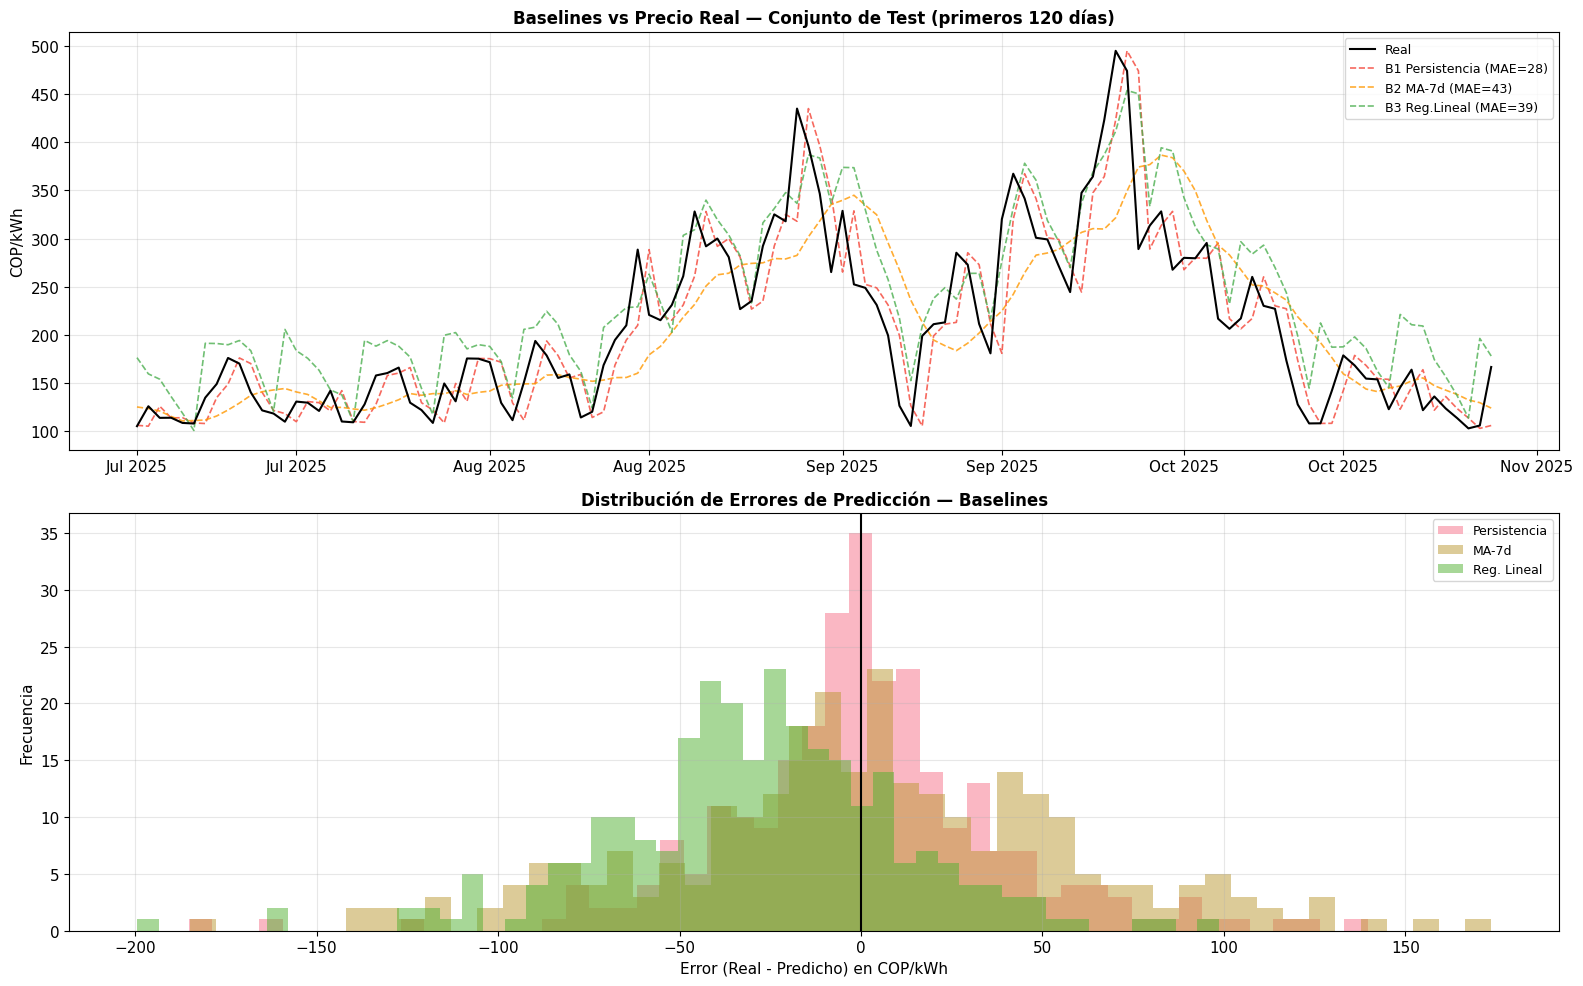

✓ Figura 7 guardada


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Predicciones vs Real (primeros 120 días del test)
n_plot = min(120, len(test))
dates_plot = test['date'].values[:n_plot]
y_real_plot = y_test.values[:n_plot]

axes[0].plot(dates_plot, y_real_plot, color='black', linewidth=1.5, label='Real', zorder=5)
axes[0].plot(dates_plot, y_persist_test[:n_plot], color='#F44336', linewidth=1.2,
             linestyle='--', alpha=0.8, label=f"B1 Persistencia (MAE={calcular_metricas(y_test.values,y_persist_test,'x')['MAE']:.0f})")
axes[0].plot(dates_plot, y_ma7_test[:n_plot], color='#FF9800', linewidth=1.2,
             linestyle='--', alpha=0.8, label=f"B2 MA-7d (MAE={calcular_metricas(y_test.values,y_ma7_test,'x')['MAE']:.0f})")
axes[0].plot(dates_plot, y_lr_test[:n_plot], color='#4CAF50', linewidth=1.2,
             linestyle='--', alpha=0.8, label=f"B3 Reg.Lineal (MAE={calcular_metricas(y_test.values,y_lr_test,'x')['MAE']:.0f})")
axes[0].set_title('Baselines vs Precio Real — Conjunto de Test (primeros 120 días)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('COP/kWh')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Distribución de errores
errors = {
    'Persistencia': y_test.values - y_persist_test,
    'MA-7d': y_test.values - y_ma7_test,
    'Reg. Lineal': y_test.values - y_lr_test,
}
for name, err in errors.items():
    axes[1].hist(err, bins=50, alpha=0.5, label=name)
axes[1].axvline(0, color='black', linewidth=1.5)
axes[1].set_title('Distribución de Errores de Predicción — Baselines', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Error (Real - Predicho) en COP/kWh')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig7_baselines_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figura 7 guardada")


## 9. Conclusiones de la Entrega 1

### ¿Qué problema intenta resolver?
Predecir el precio de bolsa ponderado nacional de energía eléctrica en Colombia para el día siguiente (*day-ahead*), usando variables del mercado disponibles en la API XM/SIMEM.

### ¿Por qué este conjunto de datos es adecuado?
- Los datos provienen directamente de XM, el operador oficial del mercado eléctrico colombiano
- Cubren 3 años de información (2023-2026) con granularidad diaria
- Incluyen las variables que la literatura identifica como drivers fundamentales del precio: hidrología, demanda y generación
- Son datos reproducibles y de acceso público

### ¿Qué métrica es razonable y por qué?
- **MAE (principal):** directamente interpretable en COP/kWh; robusto a outliers extremos de El Niño
- **RMSE (complementaria):** detecta si el modelo falla en días de alta volatilidad
- El precio tiene alta variabilidad (CV > 100%), por lo que se reportan también como porcentaje de la media

### ¿Cuál es el baseline y qué tan difícil parece el problema?
Se construyeron tres baselines:
1. **Persistencia** — el más simple: precio_mañana = precio_hoy
2. **Media móvil 7 días** — suaviza la volatilidad reciente
3. **Regresión Lineal con lags** — primer modelo con entrenamiento

El problema es de **dificultad media-alta**: el precio tiene alta volatilidad y eventos extremos (picos >1,000 COP/kWh), pero también tiene autocorrelación fuerte a 1-2 días que los modelos pueden aprovechar.

### Hallazgos clave del EDA
- Correlaciones más fuertes con el precio: MPO (>0.8), Gen. Térmica (positiva), Reservas Hidráulicas (negativa)
- Alta asimetría positiva: la media supera la mediana, indicando outliers al alza
- Patrón estacional: precios más altos en temporada seca (dic-mar)
- La Regresión Lineal ya supera a los baselines de persistencia, confirmando que los lags del precio son informativos

### Próximos pasos (Entrega 2)
- Comparar XGBoost, LightGBM y SARIMAX vs. los baselines
- Validación temporal walk-forward
- Análisis de importancia de features con SHAP


In [16]:
# Guardar el dataset procesado para la Entrega 2
df_model.to_csv('../data/raw/dataset_procesado.csv', index=False)
print(f"✓ Dataset procesado guardado: {df_model.shape[0]} filas × {df_model.shape[1]} columnas")
print(f"✓ Figuras generadas en: {FIGURES_DIR}")
print("\n=== RESUMEN ENTREGA 1 ===")
print(f"Dataset: 7 variables de mercado XM/SIMEM")
print(f"Rango: 2023-02-01 a 2026-03-31 ({len(df_model)} días)")
print(f"Features totales: {len(FEATURES)}")
print(f"Split: Train={len(train)} | Val={len(val)} | Test={len(test)}")
print(f"\nBaseline Persistencia — MAE test: {calcular_metricas(y_test.values,y_persist_test,'x')['MAE']:.2f} COP/kWh")
print(f"Baseline MA-7d        — MAE test: {calcular_metricas(y_test.values,y_ma7_test,'x')['MAE']:.2f} COP/kWh")
print(f"Baseline Reg.Lineal   — MAE test: {calcular_metricas(y_test.values,y_lr_test,'x')['MAE']:.2f} COP/kWh")


✓ Dataset procesado guardado: 1125 filas × 30 columnas
✓ Figuras generadas en: ../figures

=== RESUMEN ENTREGA 1 ===
Dataset: 7 variables de mercado XM/SIMEM
Rango: 2023-02-01 a 2026-03-31 (1125 días)
Features totales: 22
Split: Train=670 | Val=181 | Test=274

Baseline Persistencia — MAE test: 27.65 COP/kWh
Baseline MA-7d        — MAE test: 43.41 COP/kWh
Baseline Reg.Lineal   — MAE test: 38.75 COP/kWh
